# How pseudopeople noises the census: answers to Dan Weinberg's questions

Dan Weinberg, at the Census Bureau's Center for Statistical Research and Methodology, sent me seven questions about how pseudopeople generates noise and duplicate records in its decennial census dataset. The documentation answers some of them and is ambiguous on others, so this notebook answers each one twice: once by reading the code, and once by running pseudopeople on the 10,000-record sample census and counting what comes out. Where the code and the documentation disagree, I say so.

I used pseudopeople 1.2.8, the current release on PyPI. The noise code on the `main` branch is identical apart from pandas 3 support, so everything below applies to the development version as well. Each section links to the code that implements the behavior. Links to code point at the [v1.2.8 tag](https://github.com/ihmeuw/pseudopeople/tree/v1.2.8) of the repository, so that line numbers stay put, and links to documentation source point at `main`, which is what Read the Docs publishes as "latest".

**TL;DR**

| Question | Answer |
|---|---|
| Is only one kind of noise allowed per first name? | No. Noise types run one after another, each choosing its cells independently, so a name can get a nickname and then a typo. The exception is blanking, which runs first and protects the blank cell from all later noise. |
| How is a nickname chosen? | Uniformly among the nicknames listed for that exact name in the packaged table of 1,080 names. Names not in the table are never nicknamed, and the selection rate is scaled up so that 1% of *all* first names change. |
| Is a fake name uniform? | Yes, uniform over a fixed list of 90 fake first names (87 fake last names) from NORC's 2011 PVS assessment report. |
| The OCR link is dead | It points at a `develop` branch that no longer exists. The file is on `main`, and it also ships inside the package. |
| Can more than one ZIP digit be wrong? | Yes. Each of the five digits is corrupted independently (4%, 4%, 20%, 36%, 36% by default), and a wrong digit is uniform over the nine other digits. |
| What does the 2% in duplicate-with-guardian mean? | Each *eligible* child (one with a guardian recorded at a different address) is duplicated with probability 2%. Dan's 100 eligible children yield 2 expected duplicates, not 20, and nothing is guaranteed. The documented "maximum" describes a scaling step the code does not perform. |
| Other ways to create duplicates? | Not in the package. Generic duplication is a commented-out stub. Dan's two-seed workaround is sound with two adjustments. |

In [1]:
import os, copy, functools, warnings
os.environ["TQDM_DISABLE"] = "1"                      # keep progress bars out of the outputs
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import pseudopeople as psp
from pseudopeople.noise_entities import NOISE_TYPES
from pseudopeople.entity_types import ColumnNoiseType
from pseudopeople.schema_entities import COLUMNS
from pseudopeople.constants import paths
from loguru import logger
logger.disable("pseudopeople")                        # its warnings are shown once, on purpose, in Section 6

print("pseudopeople", psp.__version__, "| pandas", pd.__version__)
pd.set_option("display.width", 120)

# Chart style: thin marks, recessive axes, one blue for observed values, gray for expectations.
BLUE, GRAY, GRID = "#2a78d6", "#52514e", "#e1e0d9"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "axes.grid.axis": "y", "grid.color": GRID,
                     "axes.axisbelow": True, "figure.dpi": 110})

pseudopeople 1.2.8 | pandas 2.3.3


In [2]:
# Every experiment below starts from a configuration with *all* noise turned off and switches on
# exactly the noise type under study, so that each count has one cause.
NO_NOISE = psp.get_config(psp.NO_NOISE)

def generate(overrides=None, seed=0):
    '''Sample 2020 census with only the overridden noise parameters turned on.

    `overrides` maps a path inside the decennial_census configuration to a value, e.g.
    {("column_noise", "first_name", "use_nickname", "cell_probability"): 1.0}.
    '''
    config = copy.deepcopy(NO_NOISE)
    for path, value in (overrides or {}).items():
        node = config["decennial_census"]
        for key in path[:-1]:
            node = node[key]
        node[path[-1]] = value
    return psp.generate_decennial_census(seed=seed, config=config)

clean = generate()   # no noise at all: the truth to compare against
truth = clean.set_index("simulant_id")
print(f"{len(clean):,} records in the 2020 sample census, {clean.simulant_id.nunique():,} distinct simulants")

10,387 records in the 2020 sample census, 10,387 distinct simulants


## 1. Can more than one kind of noise hit the same first name?

> There are 6 different types of noise for this column with 1% default probabilities: Leave a field blank, Use a nickname, Use a fake name, Make phonetic errors, Make OCR errors, Make typos. Is only one type of error allowed to occur? If it's chosen to be blank, additional noise could not occur, for example.

No, the six types are not mutually exclusive, with one exception. pseudopeople applies noise types one after another in a fixed order, which is set by the position of each type in the `__NoiseTypes` container in [noise_entities.py](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/noise_entities.py#L13-L114) and walked by the loop in [noise_dataset](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/noise.py#L68-L113); the next cell prints that order, followed by the six types that apply to `first_name` in the census ([schema_entities.py](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/schema_entities.py#L260-L270)). Each type draws its own cells with its own random numbers ([get_index_to_noise](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/utilities.py#L66-L105) seeds a generator from the noise type and column name), so the cells one type touches are independent of the cells another type touches. Blanking is the exception: it runs before every other column noise type, blank cells are [excluded from later selection](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/utilities.py#L79-L83), and the blanks that a run creates are [added to that exclusion](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/noise.py#L111-L113) as soon as the blanking step finishes, so a blanked name stays blank rather than receiving a nickname on top. Everything after blanking stacks. A name can be replaced by a nickname and then acquire a typo, and at 1% per type roughly 10 pairs × 0.01² × 10,000 ≈ 10 first names in the sample get hit twice.

The documentation says that noise is [independent *between columns*](https://github.com/ihmeuw/pseudopeople/blob/main/docs/source/noise/column_noise.rst#L10-L14) and that noise types are [applied in the order listed](https://github.com/ihmeuw/pseudopeople/blob/main/docs/source/noise/index.rst#L45), but it never says in so many words that several types can land on one cell, which I take to be the source of the question. pseudopeople keeps no log of which cell got which noise, so to show the stacking I wrap each column noise function with a few lines that record the cells it receives and what it returns; [`ColumnNoiseType.__call__`](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/entity_types.py#L88-L137) hands each function exactly the cells it selected, and the wrapper changes nothing about the results.

In [3]:
print("Order in which noise types are applied:")
print("   " + " > ".join(nt.name for nt in NOISE_TYPES))
print("\nOf these, first_name in the census gets:", [nt.name for nt in COLUMNS.first_name.noise_types])

Order in which noise types are applied:
   duplicate_with_guardian > do_not_respond > omit_row > leave_blank > choose_wrong_option > copy_from_household_member > swap_month_and_day > write_wrong_zipcode_digits > misreport_age > write_wrong_digits > use_nickname > use_fake_name > make_phonetic_errors > make_ocr_errors > make_typos

Of these, first_name in the census gets: ['leave_blank', 'use_nickname', 'use_fake_name', 'make_phonetic_errors', 'make_ocr_errors', 'make_typos']


In [4]:
# Record, for every column noise type, which first_name cells it was handed and what it did to them.
events = []

def recording(noise_type):
    original = noise_type.noise_function
    @functools.wraps(original)
    def wrapped(data, configuration, randomness_stream, dataset_name, column_name):
        before = data[column_name].copy()               # copy first: some noise functions edit in place
        after = original(data, configuration, randomness_stream, dataset_name, column_name)
        if column_name == "first_name":
            for row, b, a in zip(data.index, before.values, pd.Series(after).loc[data.index].values):
                events.append({"noise_type": noise_type.name, "row": row, "before": b, "after": a})
        return after
    return original, wrapped

column_types = [nt for nt in NOISE_TYPES if isinstance(nt, ColumnNoiseType)]
saved = {}
for nt in column_types:
    saved[nt.name], nt.noise_function = recording(nt)

default_run = psp.generate_decennial_census(seed=0)      # every default noise type, nothing overridden

for nt in column_types:                                   # put the originals back
    nt.noise_function = saved[nt.name]

events = pd.DataFrame(events)
events["changed"] = events.before.astype(str) != events.after.astype(str)
events.groupby("noise_type", sort=False).agg(cells_selected=("row", "size"), cells_changed=("changed", "sum"))

,cells_selected,cells_changed
noise_type,,
leave_blank,125,125
use_nickname,175,106
use_fake_name,101,101
make_phonetic_errors,93,35
make_ocr_errors,114,18
make_typos,83,43


In [5]:
hits = events.groupby("row").noise_type.agg(list)
print("First-name cells by the number of noise types that selected them:")
print(hits.str.len().value_counts().sort_index().rename_axis("noise types").to_frame("cells").to_string())

blanked = set(events.loc[events.noise_type == "leave_blank", "row"])
touched_later = set(events.loc[events.noise_type != "leave_blank", "row"])
print(f"\nBlanked cells that a later noise type selected: {len(blanked & touched_later)}")

First-name cells by the number of noise types that selected them:
             cells
noise types       
1              671
2               10

Blanked cells that a later noise type selected: 0


In [6]:
# The cells that two noise types selected, in the order the noise was applied.
step = {nt.name: i for i, nt in enumerate(NOISE_TYPES)}
twice = events[events.row.isin(hits.index[hits.str.len() >= 2])].assign(step=lambda d: d.noise_type.map(step))
twice.sort_values(["row", "step"])[["row", "noise_type", "before", "after", "changed"]].reset_index(drop=True)

,row,noise_type,before,after,changed
0,145,make_phonetic_errors,Dorothy,Dorothy,False
1,145,make_ocr_errors,Dorothy,Dorothv,True
2,390,use_fake_name,Kenneth,Son Of,True
3,390,make_phonetic_errors,Son Of,Son Of,False
4,1687,use_nickname,Carolyn,Lynn,True
5,1687,use_fake_name,Lynn,Moh,True
6,1975,make_phonetic_errors,Margaret,Margaart,True
7,1975,make_typos,Margaart,Jaryaart,True
8,2120,make_phonetic_errors,Chelsea,Chelzea,True
9,2120,make_ocr_errors,Chelzea,Chelzea,False


Two things in these tables deserve a word. First, being selected is not the same as being changed. The nickname step selects about 1.7% of cells but changes only the ones whose name has an entry in the nickname table, which is how it ends up changing 1% of all names (Section 2). The phonetic, OCR and typo steps select 1% of cells and then corrupt each eligible token with probability 10%, so a short name with few eligible tokens often comes through a selected cell unchanged; for OCR errors only about one selected name in six actually changes. This matters if you calibrate noise by counting changed cells, because the realized rates for the token-level noise types are well below the nominal 1%. Second, the doubly-selected cells show the stacking directly: Margaret becomes Margaart by a phonetic error and then Jaryaart by two typos, and a fake name can pick up a phonetic error of its own.

## 2. How is the nickname chosen?

> "Use a nickname" says that it replaces the name with any nickname. How is this chosen? Uniformly random?

Uniformly at random among the nicknames listed for that exact name. [use_nicknames](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/noise_functions.py#L555-L582) looks each selected name up in the packaged table ([data/nicknames.csv](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/data/nicknames.csv), from Carlton Northern's nickname project), which has 1,080 names with up to 15 nicknames each, and [two_d_array_choice](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/utilities.py#L129-L171) gives every listed nickname the same weight, so a selected William becomes one of his eight listed nicknames with probability 1/8 each, and a name with no entry, which is about 40% of first names in the census, is never nicknamed. To keep the configured rate meaningful, pseudopeople scales the selection probability up by one over the eligible share ([scale_nicknames](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/noise_scaling.py#L26-L34), applied and [capped at 1.0](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/entity_types.py#L100-L105)), so a `cell_probability` of 1% changes 1% of all first names rather than 0.6% of them. This scaling is also where the documentation's notion of a "maximum" comes from: above a `cell_probability` of about 0.6 every eligible name is already a nickname, the remaining 40% cannot be, and the package logs a warning (silenced in this notebook) and does what it can.

In [7]:
from pseudopeople.noise_scaling import load_nicknames_data
nicknames = load_nicknames_data()
eligible_share = clean.first_name.isin(nicknames.index).mean()
print(f"{len(nicknames):,} names in the table; {eligible_share:.1%} of first names in the sample census have an entry\n")
for name in ["William", "Elizabeth", "Daniel", "Abraham"]:
    print(f"{name}: {nicknames.loc[name].dropna().tolist() if name in nicknames.index else 'no entry'}")

1,080 names in the table; 59.6% of first names in the sample census have an entry

William: ['Willy', 'Bell', 'Bela', 'Bill', 'Will', 'Billy', 'Willie', 'Wil']
Elizabeth: ['Libby', 'Lisa', 'Lib', 'Lizzy', 'Lizzie', 'Eliza', 'Betsy', 'Liza', 'Betty', 'Bessie', 'Bess', 'Beth', 'Liz']
Daniel: ['Dan', 'Danny', 'Dann']
Abraham: ['Ab', 'Abe']


In [8]:
NICKNAME = ("column_noise", "first_name", "use_nickname", "cell_probability")
runs = []
for seed in range(10):                                    # 10 seeds, every eligible name replaced
    recorded = generate({NICKNAME: 1.0}, seed=seed).set_index("simulant_id").first_name
    runs.append(pd.DataFrame({"original": truth.first_name, "recorded": recorded}))
runs = pd.concat(runs)
changed = runs.original != runs.recorded
print(f"With cell_probability = 1: {changed.mean():.1%} of first names changed versus {eligible_share:.1%} eligible; "
      f"changes among names with no entry: {(changed & ~runs.original.isin(nicknames.index)).sum()}")

for name in ["William", "Elizabeth"]:
    options = nicknames.loc[name].dropna().tolist()
    got = runs.loc[runs.original == name, "recorded"]
    counts = got.value_counts().reindex(options, fill_value=0)
    print(f"\n{name}: {len(got)} selected over 10 seeds, {len(options)} listed nicknames, expected {len(got) / len(options):.0f} each; "
          f"chi-square p = {stats.chisquare(counts).pvalue:.2f}; outputs not on the list: {set(got) - set(options) or 'none'}")
    print(counts.to_string())

With cell_probability = 1: 59.6% of first names changed versus 59.6% eligible; changes among names with no entry: 0

William: 1180 selected over 10 seeds, 8 listed nicknames, expected 148 each; chi-square p = 0.37; outputs not on the list: none
recorded
Willy     136
Bell      159
Bela      170
Bill      137
Will      147
Billy     154
Willie    143
Wil       134

Elizabeth: 620 selected over 10 seeds, 13 listed nicknames, expected 48 each; chi-square p = 0.43; outputs not on the list: none
recorded
Libby     39
Lisa      64
Lib       47
Lizzy     50
Lizzie    49
Eliza     40
Betsy     44
Liza      50
Betty     49
Bessie    47
Bess      41
Beth      57
Liz       43


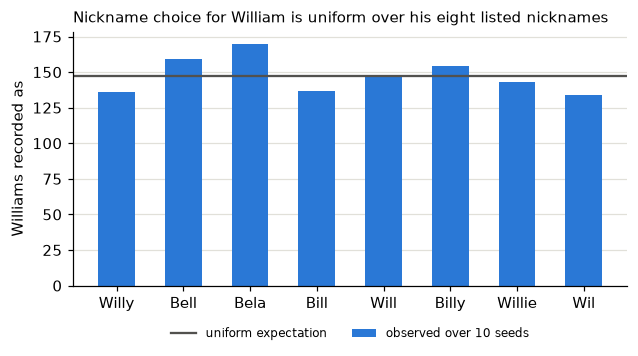

In [9]:
options = nicknames.loc["William"].dropna().tolist()
counts = runs.loc[runs.original == "William", "recorded"].value_counts().reindex(options, fill_value=0)
fig, ax = plt.subplots(figsize=(6.5, 3))
ax.bar(counts.index, counts.values, color=BLUE, width=0.55, label="observed over 10 seeds")
ax.axhline(counts.sum() / len(options), color=GRAY, lw=1.5, label="uniform expectation")
ax.set_ylabel("Williams recorded as")
ax.set_title("Nickname choice for William is uniform over his eight listed nicknames", fontsize=10, loc="left")
ax.legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
plt.show()

In [10]:
rates = [(truth.first_name != generate({NICKNAME: 0.01}, seed=seed).set_index("simulant_id").first_name).mean()
         for seed in range(10)]
print(f"At the default cell_probability = 0.01, {np.mean(rates):.2%} of all first names become nicknames (mean of 10 seeds),")
print(f"even though only {eligible_share:.1%} of names are eligible, because the selection rate is scaled up by 1 / {eligible_share:.3f}.")

At the default cell_probability = 0.01, 1.07% of all first names become nicknames (mean of 10 seeds),
even though only 59.6% of names are eligible, because the selection rate is scaled up by 1 / 0.596.


## 3. Is the fake name uniform?

> "Use a fake name" says that it randomly picks a fake name. Is it uniformly random?

Yes. [use_fake_names](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/noise_functions.py#L585-L626) draws from a fixed Python list with equal probability ([vectorized_choice](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/utilities.py#L28-L63) with no weights): the 90 fake first names and 87 fake last names in [data/fake_names.py](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/data/fake_names.py), transcribed from the "names considered fake or incomplete" lists in NORC's 2011 assessment of the Census Bureau's Person Identification Validation System. The lists are what a reluctant respondent writes, "Girl", "Adult Male", "Lady Of The House", "Refuse", rather than plausible invented names, so a fake name is usually easy to spot and impossible to link. The only fake first name that is also a real first name in the sample census is Baby.

In [11]:
from pseudopeople.data.fake_names import fake_first_names, fake_last_names
print(len(fake_first_names), "fake first names:", ", ".join(sorted(fake_first_names)))
print("\n" + str(len(fake_last_names)), "fake last names:", ", ".join(sorted(fake_last_names)))

90 fake first names: A, Adult, Adult Male, B, Baby, Boy, Brother, C, Child, Child F, Coh, D, Dad, Dau, Daughter, Daughter Of, Doh, E, F, Father, Female, Female Child, Friend, G, Gent, Gentelman, Gentle, Gentleman, Gentleman Of, Gentlemen, Girl, Goh, Grandchild, Granddaughter, Grandson, H, Hija, Hijo, House, Husband, Inmate, J, K, Kid, L, Lady, Lady In The, Lady Of, Lady Of House, Lady Of The, Loh, M, Male, Male Child, Man, Man In The, Man Of, Man Of The, Minor, Miss, Moh, Mom, Mother, Mr, Mrs, Ms, N, Nephew, Nino, O, Oldest, One, P, Person, R, Resident, Respondent, S, Senor, Senora, Sister, Soh, Son, Son Of, T, V, W, Wife, Woman, Youngest

87 fake last names: A, Adult, Anon, Anonymous, Apellido, B, Boy, C, Casa, Child, Coh, D, Daughter, De Casa, De La Casa, Declined, Doe, Doh, Dont Know, E, F, Female, Four, Friend, G, Girl, Goh, H, H Age, Hh, Hhm, Home, House, Household, Householder, Husband, J, K, L, Lady, Lady Of House, Lady Of The House, Last Name, Loh, M, Male, Man, Man Of The Hous

All 10,387 first names replaced; 90 distinct values, all from the list: True
Records per fake name: min 97, mean 115.4, max 135; chi-square p for uniformity = 0.98


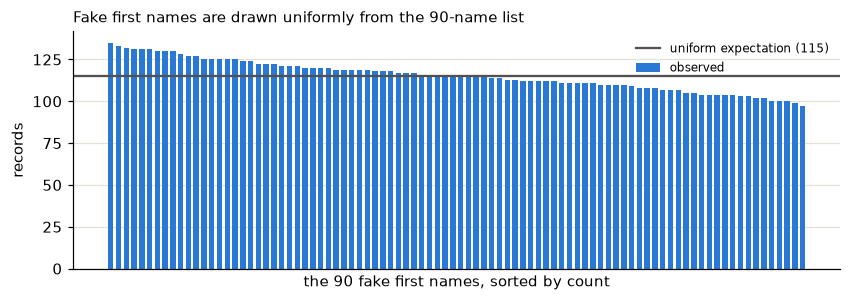

In [12]:
FAKE = ("column_noise", "first_name", "use_fake_name", "cell_probability")
recorded = generate({FAKE: 1.0}).first_name
counts = recorded.value_counts().reindex(fake_first_names, fill_value=0)
print(f"All {len(recorded):,} first names replaced; {recorded.nunique()} distinct values, "
      f"all from the list: {set(recorded) <= set(fake_first_names)}")
print(f"Records per fake name: min {counts.min()}, mean {counts.mean():.1f}, max {counts.max()}; "
      f"chi-square p for uniformity = {stats.chisquare(counts).pvalue:.2f}")

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.bar(range(len(counts)), counts.sort_values(ascending=False).values, color=BLUE, width=0.7, label="observed")
ax.axhline(counts.mean(), color=GRAY, lw=1.5, label=f"uniform expectation ({counts.mean():.0f})")
ax.set_xticks([])
ax.set_xlabel("the 90 fake first names, sorted by count")
ax.set_ylabel("records")
ax.set_title("Fake first names are drawn uniformly from the 90-name list", fontsize=10, loc="left")
ax.legend(frameon=False, fontsize=8)
plt.show()

## 4. The dead OCR link

> The other error types here are clear, but I noticed that a link for OCR errors is dead: File not found · GitHub

The documentation links to `https://github.com/ihmeuw/pseudopeople/blob/develop/src/pseudopeople/data/ocr_errors.csv` ([column_noise.rst, line 345](https://github.com/ihmeuw/pseudopeople/blob/main/docs/source/noise/column_noise.rst#L345)), and the repository no longer has a `develop` branch. The default branch is `main`, where the file is at <https://github.com/ihmeuw/pseudopeople/blob/main/src/pseudopeople/data/ocr_errors.csv>, and the [phonetic-variations link](https://github.com/ihmeuw/pseudopeople/blob/main/docs/source/noise/column_noise.rst#L317) on the same page has the same problem (working link: <https://github.com/ihmeuw/pseudopeople/blob/main/src/pseudopeople/data/phonetic_variations.csv>). Both files also ship inside the installed package, which is the surest place to read them, and the cell below prints the OCR table from there as [load_ocr_errors](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/utilities.py#L298-L308) parses it. It holds 49 confusion rules from the GeCO project (Christen and Vatsalan, 2013): a token on the left is misread as the string on the right, some tokens have several possible misreadings, and a few rules change the length of the string (`m` to `rn`, `cl` to `d`). Within a selected cell, [make_ocr_errors](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/noise_functions.py#L761-L785) hands the table to [_corrupt_tokens](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/noise_functions.py#L788-L929), which misreads each occurrence of a token with the token probability, chooses one of its misreadings uniformly when there are several, and never corrupts a stretch of the string that has already been corrupted.

In [13]:
from pseudopeople.utilities import load_ocr_errors
rules = pd.read_csv(paths.OCR_ERRORS_DATA, comment="#", header=None, names=["token", "misread as"], quoting=3)
print(f"{paths.OCR_ERRORS_DATA}\n{len(rules)} rules covering {rules.token.nunique()} distinct tokens\n")
ocr = load_ocr_errors()
print(ocr.apply(lambda r: ", ".join(r.dropna()), axis=1).rename("possible misreadings").to_string())

/home/user/ai_assisted_research/pseudopeople_noise_questions/.venv/lib/python3.11/site-packages/pseudopeople/data/ocr_errors.csv
49 rules covering 39 distinct tokens

0            o, O
1               |
12              R
13              B
17              n
1<              k
1>              b
2            Z, z
5            S, s
6               G
A               4
B               8
D               O
E               F
F               P
I-I             H
IJ              U
LI              U
Q               O
U               V
Y               V
cl              d
g            9, q
h               b
i           'l, :
iii             m
j               i
k              lc
l      J, 1, I, |
l<              k
l>              b
lJ              U
lo              b
m           n, rn
q            9, 4
ri              n
u               v
w              vv
y               v


In [14]:
OCR_CELL = ("column_noise", "first_name", "make_ocr_errors", "cell_probability")
OCR_TOKEN = ("column_noise", "first_name", "make_ocr_errors", "token_probability")
misread = generate({OCR_CELL: 1.0, OCR_TOKEN: 1.0}).set_index("simulant_id").first_name
pairs = pd.DataFrame({"original": truth.first_name, "misread": misread})
pairs = pairs[pairs.original != pairs.misread]
print(f"With every eligible token misread, {len(pairs):,} of {len(truth):,} first names change; the rest contain no token from the table.")
pairs.drop_duplicates().head(12)

With every eligible token misread, 9,433 of 10,387 first names change; the rest contain no token from the table.


,original,misread
simulant_id,,
0_2,Diana,O'lana
0_3,Anna,4nna
0_923,Gerald,Gera|d
0_2801,Richard,R:cbard
0_13972,Jerry,Jerrv
0_13973,Anita,4n'lta
0_13975,Toni,Ton'l
0_4,Eric,Fnc
0_5,Erin,Fnn


## 5. Can more than one ZIP code digit be wrong?

> For "Write the Wrong ZIP code digits", can only one of the digits be corrupted? And is the wrong digit drawn uniformly from the remaining digits?

More than one digit can be wrong, and a wrong digit is uniform over the nine other digits. Within a ZIP code selected for this noise type (1% of cells by default), each of the five positions is corrupted independently with its own probability, 4%, 4%, 20%, 36% and 36% from left to right ([the defaults](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/noise_entities.py#L59-L66)), on the reasoning that people know their region better than their block. Internally [write_wrong_zipcode_digits](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/noise_functions.py#L407-L459) draws the replacement from all ten digits and [scales each position's probability by 10/9](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/noise_functions.py#L438-L448), so the draws that reproduce the original digit wash out, and the net effect is the configured rate with a uniform choice among the other nine. The expected number of wrong digits in a selected ZIP code is therefore 0.04 + 0.04 + 0.20 + 0.36 + 0.36 = 1.0, but the count varies: about 30% of selected ZIP codes come through with no error at all, 44% with one, 22% with two, and 4% with three or more. The realized rate of changed ZIP codes at the default settings is about 0.7%, not 1%.

The sample census anonymizes addresses, and every ZIP code in it is 00000. This is a limitation for the demonstration but not for the logic: a wrong digit then has to be one of 1 through 9, and the test of uniformity is whether those nine come up equally often.

In [15]:
ZIP = ("column_noise", "zipcode", "write_wrong_zipcode_digits", "cell_probability")
digit_p = np.array(psp.get_config()["decennial_census"]["column_noise"]["zipcode"]["write_wrong_zipcode_digits"]["digit_probabilities"])
print("default digit_probabilities:", digit_p.tolist())

original = truth.zipcode.astype(str)
recorded = generate({ZIP: 1.0}).set_index("simulant_id").zipcode.astype(str).loc[original.index]
wrong = np.array([[a != b for a, b in zip(o, r)] for o, r in zip(original, recorded)])   # records x 5 positions

per_position = pd.DataFrame({"configured": digit_p, "observed share wrong": wrong.mean(axis=0)},
                            index=[f"digit {i + 1}" for i in range(5)])
per_position.round(3)

default digit_probabilities: [0.04, 0.04, 0.2, 0.36, 0.36]


,configured,observed share wrong
digit 1,0.04,0.040
digit 2,0.04,0.039
digit 3,0.20,0.207
digit 4,0.36,0.364
digit 5,0.36,0.361


In [16]:
from itertools import product
predicted = np.zeros(6)
for bits in product([0, 1], repeat=5):
    predicted[sum(bits)] += np.prod([p if b else 1 - p for p, b in zip(digit_p, bits)])
n_wrong = pd.Series(wrong.sum(axis=1)).value_counts(normalize=True).reindex(range(6), fill_value=0)
pd.DataFrame({"share of selected ZIP codes": n_wrong.round(3),
              "predicted if positions are independent": predicted.round(3)}).rename_axis("wrong digits")

,share of selected ZIP codes,predicted if positions are independent
wrong digits,,
0,0.296,0.302
1,0.443,0.440
2,0.220,0.216
3,0.039,0.040
4,0.002,0.002
5,0.000,0.000


Digit written in place of the true 0:
1    1140
2    1215
3    1201
4    1218
5    1110
6    1132
7    1137
8    1155
9    1183
chi-square p for uniformity over 1 through 9: 0.22


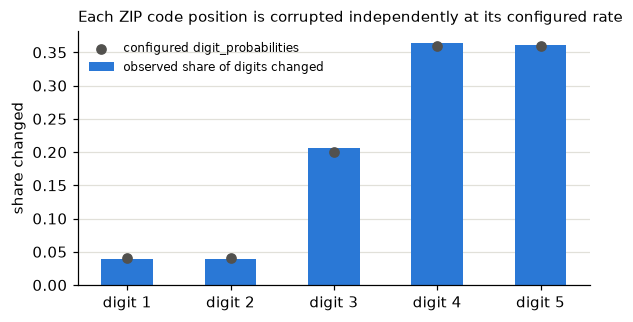

In [17]:
new_digits = pd.Series([r[i] for o, r in zip(original, recorded) for i in range(5) if o[i] != r[i]])
counts = new_digits.value_counts().sort_index()
print("Digit written in place of the true 0:")
print(counts.to_string())
print(f"chi-square p for uniformity over 1 through 9: {stats.chisquare(counts).pvalue:.2f}")

fig, ax = plt.subplots(figsize=(6, 3))
x = np.arange(5)
ax.bar(x, per_position["observed share wrong"], color=BLUE, width=0.5, label="observed share of digits changed")
ax.scatter(x, per_position.configured, color=GRAY, zorder=3, s=36, label="configured digit_probabilities")
ax.set_xticks(x, per_position.index)
ax.set_ylabel("share changed")
ax.set_title("Each ZIP code position is corrupted independently at its configured rate", fontsize=10, loc="left")
ax.legend(frameon=False, fontsize=8)
plt.show()

## 6. Duplicate with guardian: what does the 2% refer to?

> Consider all simulants under 18 years: say that there are 1000 of such simulants. Assume that 100 of them have guardians at two different addresses. In the original dataset, they are at one location. With the default parameter of 2%, what happens? Are you duplicating each of the 100 with probability 2%, so 2 duplicates would be expected? If so, how can there be a maximum probability? This only makes sense if there can be a guarantee that all eligible children are duplicated. Or is the 2% referring to the 1000, so that we would expect (or guarantee) that there are 20 duplicates? I have similar questions about the college students in Group Quarters.

Dan's first reading is the right one: each of the 100 eligible children is duplicated with probability 2%, so 2 duplicates are expected, the count is binomial, and nothing is guaranteed. Mechanically, [duplicate_with_guardian](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/noise_functions.py#L161-L303) [assembles every simulant under 18](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/noise_functions.py#L215-L224) who lives in a household and has a guardian recorded, [draws 2% of them](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/noise_functions.py#L265-L271), and then [keeps only the drawn children](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/noise_functions.py#L272-L279) whose guardian lives in a different household, since it needs an address to copy. Drawing 2% of everyone and discarding the ineligible is the same, in distribution, as drawing 2% of the eligible. The college group works identically at 5% ([the defaults](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/noise_entities.py#L24-L32)), applied to simulants under 24 in college group quarters with a guardian recorded elsewhere, and there almost everyone is eligible.

The "maximum probability" is where the documentation and the code part ways. The documentation says that ["a maximum duplication rate will be calculated based on those who have a guardian living at a different address"](https://github.com/ihmeuw/pseudopeople/blob/main/docs/source/noise/row_noise.rst#L30-L36), which is about 14% of household children nationally in 2020 and about 79% of college students according to the [metadata_proportions.csv](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/data/sample_datasets/metadata_proportions.csv) table that ships with the package, and [validate_noise_level_proportions](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/configuration/validator.py#L260-L339) warns when the configured probability exceeds that share. This would be the right description if the probability were scaled up over the eligible subset, as the nickname noise is, so that 2% meant 2% of all children. No such scaling exists for duplication: [RowNoiseType](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/entity_types.py#L31-L57) has no scaling hook, unlike [ColumnNoiseType](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/entity_types.py#L79-L105). The parameter is a per-eligible-child probability, every value up to 1.0 does something, and 1.0 duplicates every eligible child exactly once. I lean toward fixing the documentation and the warning rather than the code, since making the code match the documentation would multiply the default number of duplicates by about seven and change everyone's results, but either fix would remove the contradiction.

The guardian columns are dropped from pseudopeople's output, so the eligibility counts below come from the input file. In the sample only 155 of 2,155 household children have a guardian at a different address, well under the national 14%, which I attribute to guardians who live in households outside the 10,000-person sample and so cannot be found.

In [18]:
census_input = pd.read_parquet(paths.SAMPLE_DATA_ROOT / "decennial_census" / "decennial_census.parquet")
census_input = census_input[census_input.year == 2020].copy()
for col in ["simulant_id", "household_id", "guardian_1", "guardian_2"]:
    census_input[col] = census_input[col].astype(object)          # plain strings, NaN preserved
household_of = census_input.set_index("simulant_id").household_id

def has_guardian_elsewhere(group):
    g1, g2 = group.guardian_1.map(household_of), group.guardian_2.map(household_of)   # NaN if not in the data
    return (g1.notna() & (g1 != group.household_id)) | (g2.notna() & (g2 != group.household_id))

children = census_input[(census_input.age < 18) & (census_input.housing_type == "Household") & census_input.guardian_1.notna()]
students = census_input[(census_input.age < 24) & (census_input.housing_type == "College") & census_input.guardian_1.notna()]
eligible_children = children[has_guardian_elsewhere(children)]
eligible_students = students[has_guardian_elsewhere(students)]
print(f"Children under 18 in households with a guardian recorded: {len(children):,}; "
      f"with a guardian at a different address: {len(eligible_children)}")
print(f"College students under 24 with a guardian recorded: {len(students)}; "
      f"with a guardian at a different address: {len(eligible_students)}")

Children under 18 in households with a guardian recorded: 2,155; with a guardian at a different address: 155
College students under 24 with a guardian recorded: 55; with a guardian at a different address: 34


In [19]:
CHILDREN = ("row_noise", "duplicate_with_guardian", "row_probability_in_households_under_18")
STUDENTS = ("row_noise", "duplicate_with_guardian", "row_probability_in_college_group_quarters_under_24")

def count_duplicates(noised):
    duplicated = noised.simulant_id[noised.simulant_id.duplicated()]
    housing = truth.housing_type.loc[duplicated]
    return pd.Series({"children": (housing == "Household").sum(), "students": (housing == "College").sum()})

trials = pd.DataFrame([count_duplicates(generate({CHILDREN: 0.02, STUDENTS: 0.05}, seed=seed)) for seed in range(20)])
print("Duplicates per run at the default 2% / 5%, over 20 seeds:")
print(trials.describe().loc[["mean", "std", "min", "max"]].round(2).to_string())
print("\nExpected duplicates under each reading of the parameter:")
print(pd.Series({"2% of eligible children": 0.02 * len(eligible_children),
                 "2% of all children": 0.02 * len(children),
                 "all eligible children": len(eligible_children),
                 "5% of eligible students": 0.05 * len(eligible_students),
                 "5% of all students": 0.05 * len(students)}).round(1).to_string())

Duplicates per run at the default 2% / 5%, over 20 seeds:
      children  students
mean      3.50      1.70
std       1.85      1.42
min       0.00      0.00
max       6.00      4.00

Expected duplicates under each reading of the parameter:
2% of eligible children      3.1
2% of all children          43.1
all eligible children      155.0
5% of eligible students      1.7
5% of all students           2.8


In [20]:
proportions = pd.read_csv(paths.METADATA_PROPORTIONS)
documented_max = proportions[(proportions.dataset == "decennial_census") & (proportions.state == "USA")
                             & (proportions.year == 2020) & proportions.column.isna()].set_index("noise_type").proportion
print("Documented maxima (metadata_proportions.csv, USA, 2020):")
print(documented_max.round(3).to_string(), "\n")

for p in [0.02, documented_max["row_probability_in_households_under_18"], 0.5, 1.0]:
    if p == 0.5:
        logger.enable("pseudopeople")                 # let the package's warning through once
    extra = len(generate({CHILDREN: p})) - len(clean)
    logger.disable("pseudopeople")
    print(f"row_probability_in_households_under_18 = {p:.3f}: {extra:4d} duplicates "
          f"= {extra / len(eligible_children):4.0%} of eligible children, {extra / len(children):5.1%} of all children")
duplicated = set(generate({CHILDREN: 1.0}).simulant_id.loc[lambda s: s.duplicated()])
print("At 1.0 the duplicated children are exactly the eligible set:", duplicated == set(eligible_children.simulant_id))

for p in [0.05, 1.0]:
    extra = len(generate({STUDENTS: p})) - len(clean)
    print(f"row_probability_in_college_group_quarters_under_24 = {p:.2f}: {extra:3d} duplicates of {len(eligible_students)} eligible students")

Documented maxima (metadata_proportions.csv, USA, 2020):
noise_type
row_probability_in_households_under_18                0.138
row_probability_in_college_group_quarters_under_24    0.793 



row_probability_in_households_under_18 = 0.020:    1 duplicates =   1% of eligible children,  0.0% of all children


row_probability_in_households_under_18 = 0.138:   25 duplicates =  16% of eligible children,  1.2% of all children
2026-09-24 07:16:08.727 | pseudopeople.configuration.validator:validate_noise_level_proportions:335 - The configured 'row_probability_in_households_under_18' noise level for row_noise 'nan' is 0.5, which is higher than the maximum possible value based on the provided data for 'decennial_census'. Noising as many rows as possible. 


row_probability_in_households_under_18 = 0.500:   79 duplicates =  51% of eligible children,  3.7% of all children


row_probability_in_households_under_18 = 1.000:  155 duplicates = 100% of eligible children,  7.2% of all children


At 1.0 the duplicated children are exactly the eligible set: True


row_probability_in_college_group_quarters_under_24 = 0.05:   4 duplicates of 34 eligible students


row_probability_in_college_group_quarters_under_24 = 1.00:  34 duplicates of 34 eligible students


The warning, which I let through once above for 0.5, says pseudopeople is "noising as many rows as possible," but at 0.5 it duplicated half of the eligible children, not all of them, which is the contradiction in one line. Below is what a duplicate looks like. The [nine address-type columns](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/constants/noise_type_metadata.py#L4-L14) (street number, street name, unit, city, state, ZIP code, housing type, household id, year) come from the guardian, the relationship to the reference person becomes ["Other relative"](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/constants/noise_type_metadata.py#L34-L42), and everything else, name, age, date of birth, sex, race, is the child's own. A child is duplicated at most once, and if both guardians live elsewhere [one of them is picked at random](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/noise_functions.py#L239-L252). Duplication is the first noise step, so the duplicate row then goes through nonresponse and column noise like any other row, and at default settings either copy can be dropped by nonresponse.

In [21]:
one = generate({CHILDREN: 1.0})
simulant = one.simulant_id[one.simulant_id.duplicated()].iloc[0]
pair = one[one.simulant_id == simulant].T
pair.columns = ["original record", "duplicate at guardian's address"]
pair

,original record,duplicate at guardian's address
simulant_id,0_5337,0_5337
household_id,0_2183,0_7824
first_name,Dallas,Dallas
middle_initial,Z,Z
last_name,Lopez,Lopez
age,5,5
date_of_birth,02/04/2015,02/04/2015
street_number,1613,70
street_name,cr ledge dr,independence st
unit_number,NaN,NaN


## 7. Are there other ways to create duplicates?

> Finally, are there other ways to create duplicates outside of these 2 groups? In a 2024 referee response, you said that you planned to add "simple duplication". One workaround would be to create two datasets using different seeds, then concatenate a sample of records from the second dataset onto the first dataset.

Not in the released package. Guardian duplication is the only row-duplicating noise type; a generic `duplicate_row` exists in the source only as a commented-out stub ([noise_entities.py, line 37](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/noise_entities.py#L37) and [noise_functions.py, lines 145 to 158](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/noise_functions.py#L145-L158)), and the census dataset definition still carries a commented-out [`NOISE_TYPES.duplication`](https://github.com/ihmeuw/pseudopeople/blob/v1.2.8/src/pseudopeople/schema_entities.py#L621-L626) line, so the plan is on the record and unfinished. The next cell greps the installed source for these lines. Dan's workaround works with two adjustments. First, sample from the simulants present in both datasets: nonresponse is drawn separately for each seed, so about 1.5% of the second dataset's records belong to simulants missing from the first, and appending one of those adds a recovered non-respondent rather than a duplicate. Second, expect about half of the injected duplicates to be exact copies of their originals, because at the default noise levels a record comes through a run untouched about 70% of the time, and most of the other half differ in a single field; raising the noise levels in the second run gives duplicates that disagree with their originals more often, and how often is a choice about what kind of duplicate one wants to simulate. The one thing this workaround cannot produce is what guardian duplication produces, a second record at a different address, since both seeds start from the same underlying truth.

In [22]:
import inspect, re
from pseudopeople import noise_entities, noise_functions, schema_entities
for module in [noise_entities, noise_functions, schema_entities]:
    for number, line in enumerate(inspect.getsource(module).splitlines(), 1):
        if re.search(r"duplicat(e_row|ion)\b", line):
            print(f"{module.__name__}:{number}: {line.strip()}")

pseudopeople.noise_entities:15: do_not_respond, omit_row, duplicate_row, leave_blank, choose_wrong_option,
pseudopeople.noise_entities:37: # duplicate_row: RowNoiseType = RowNoiseType("duplicate_row", noise_functions.duplicate_rows)
pseudopeople.noise_functions:175: :param configuration: LayeredConfigTree object containing noise level values. Dict with three key groups for duplication
pseudopeople.schema_entities:625: # NOISE_TYPES.duplication,
pseudopeople.schema_entities:656: # NOISE_TYPES.duplication,
pseudopeople.schema_entities:685: # NOISE_TYPES.duplication,
pseudopeople.schema_entities:712: # NOISE_TYPES.duplication,
pseudopeople.schema_entities:733: # NOISE_TYPES.duplication,
pseudopeople.schema_entities:769: # NOISE_TYPES.duplication,


In [23]:
first = psp.generate_decennial_census(seed=0)            # default noise, two different seeds
second = psp.generate_decennial_census(seed=1)
unique_first = first[~first.simulant_id.duplicated(keep=False)].set_index("simulant_id")
unique_second = second[~second.simulant_id.duplicated(keep=False)].set_index("simulant_id")
in_both = unique_first.index.intersection(unique_second.index)
print(f"simulants in seed 0: {first.simulant_id.nunique():,}; in seed 1: {second.simulant_id.nunique():,}; "
      f"in both: {len(in_both):,}; in seed 1 only (non-respondents in seed 0): {len(unique_second.index.difference(unique_first.index))}")

injected = unique_second.loc[in_both].sample(n=200, random_state=0)
with_duplicates = pd.concat([first, injected.reset_index()], ignore_index=True)
print(f"{len(first):,} records + {len(injected)} injected duplicates = {len(with_duplicates):,} records")

differs = unique_first.loc[injected.index].astype(str) != injected.astype(str)
print(f"\nInjected duplicates that differ from their seed-0 original in at least one field: {differs.any(axis=1).mean():.0%}")
print("Fields that differ most often:")
print(differs.mean().sort_values(ascending=False).head(6).round(3).to_string())

simulants in seed 0: 10,227; in seed 1: 10,224; in both: 10,066; in seed 1 only (non-respondents in seed 0): 158
10,231 records + 200 injected duplicates = 10,431 records

Injected duplicates that differ from their seed-0 original in at least one field: 51%
Fields that differ most often:
first_name       0.085
date_of_birth    0.080
zipcode          0.055
age              0.055
city             0.055
housing_type     0.055


## Summary

Five of the seven answers are what a careful reader of the code would expect, and the runs confirm them: noise types stack except after blanking, nicknames and fake names are uniform draws, several ZIP digits can be wrong at once, and generic duplication does not exist yet. The duplicate-with-guardian answer is the one that needed the experiment, because the documentation's "maximum probability" describes a scaling step the code does not perform; the answer to Dan's question is 2 expected duplicates from 100 eligible children, with a binomial spread and no guarantee. Three things remain open on the pseudopeople side. The documentation and warning for guardian duplication should describe a per-eligible-dependent probability, or the code should scale the probability as it does for nicknames, which would change default results. The two `develop` links should point at `main`. And simple duplication is still worth adding, since the two-seed workaround cannot move a person to a new address.